In [ ]:
#

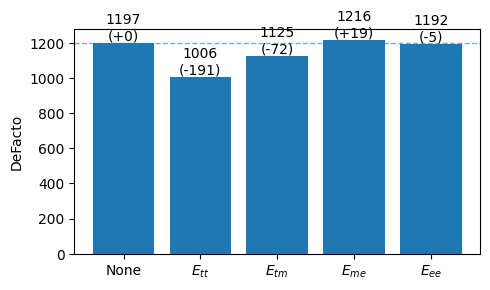

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ["None", r"$E_{tt}$", r"$E_{tm}$", r"$E_{me}$", r"$E_{ee}$"]
defacto = [1197, 1006, 1125, 1216, 1192]

baseline = 1197  # 完整图

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 3))

bars = ax.bar(x, defacto)

# baseline 虚线
ax.axhline(baseline, linestyle="--", linewidth=1, alpha=0.6)

# 轴标签和刻度
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Removed edge type")
ax.set_ylabel("DeFacto (number of correct samples)")
# ax.set_title("Edge-removal ablation")

# 在柱子上标注数值（或差值）
for xi, yi in zip(x, defacto):
    diff = yi - baseline
    # 你如果只想显示原始值，用 text = f"{yi}"
    text = f"{yi}\n({diff:+d})"   # 显示“1197 (+0) / 1006 (-191)”这种
    ax.text(
        xi,
        yi,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0,
    )

plt.tight_layout()
plt.savefig("edge_removal_ablation_bar.png", dpi=300)
plt.savefig("edge_removal_ablation_bar.eps")
plt.show()


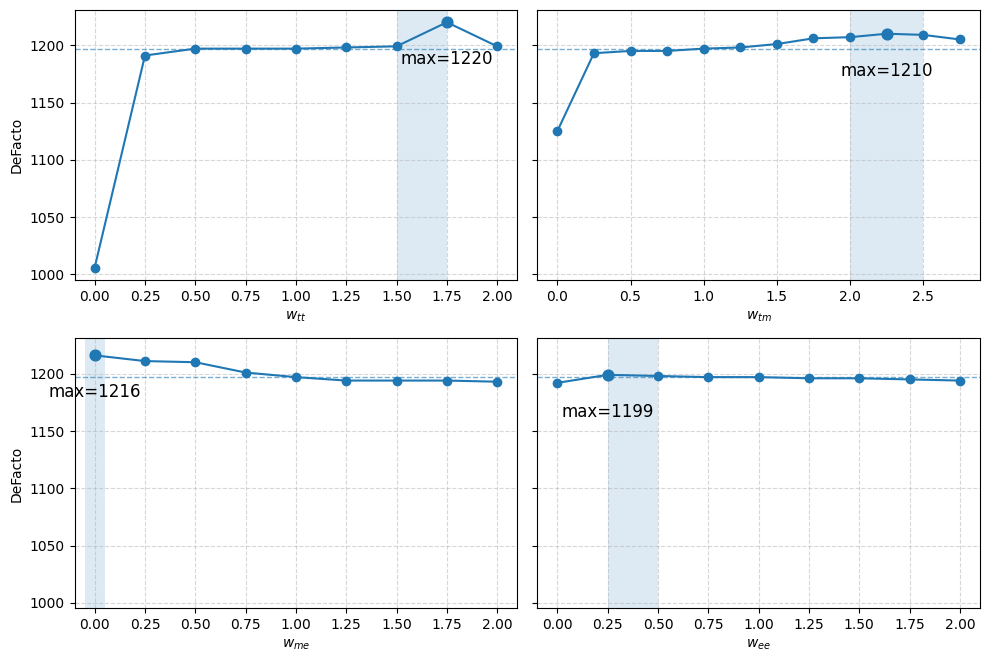

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ========= 1. 数据 =========
# (1) 扫 w_TT，其他=1
w_TT = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
defacto_TT = [1006, 1191, 1197, 1197, 1197, 1198, 1199, 1220, 1199]

# (2) 扫 w_TM，其他=1
w_TM = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75]
defacto_TM = [1125, 1193, 1195, 1195, 1197, 1198, 1201, 1206, 1207, 1210, 1209, 1205]

# (3) 扫 w_ME，其他=1
w_ME = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
defacto_ME = [1216, 1211, 1210, 1201, 1197, 1194, 1194, 1194, 1193]

# (4) 扫 w_EE，其他=1
w_EE = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
defacto_EE = [1192, 1199, 1198, 1197, 1197, 1196, 1196, 1195, 1194]

baseline = 1197  # (1,1,1,1) 对应的 defacto

# ========= 2. 画 2×2 子图 =========
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
# fig.suptitle("Single-factor sweeps of edge weights", fontsize=14)

# 一个小工具函数：画曲线 + baseline + 高亮最优点 + 推荐区间
def plot_sweep(ax, xs, ys, xlabel, title, good_interval=None):
    xs = np.array(xs)
    ys = np.array(ys)

    # 曲线
    ax.plot(xs, ys, marker="o")
    # baseline
    ax.axhline(baseline, linestyle="--", linewidth=1, alpha=0.6)
    # 最优点
    best_idx = ys.argmax()
    ax.scatter(xs[best_idx], ys[best_idx], s=60, zorder=3)
    ax.annotate(
        f"max={ys[best_idx]}",
        xy=(xs[best_idx], ys[best_idx]),
        xytext=(0, -20),
        textcoords="offset points",
        fontsize=12,
        ha="center",                     # 水平居中
        va="top", 
    )
    # 推荐区间（浅色区域）
    if good_interval is not None:
        ax.axvspan(good_interval[0], good_interval[1], alpha=0.15)

    ax.set_xlabel(xlabel)
    # ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.5)

# (a) w_TT：推荐区间 [1.5, 1.75]
plot_sweep(
    axes[0, 0],
    w_TT,
    defacto_TT,
    xlabel=r"$w_{tt}$ (weight)",
    title="(a) Sweep of $w_{tt}$",
    good_interval=(1.5, 1.75),
)
axes[0, 0].set_ylabel("DeFacto (number of correct samples)")

# (b) w_TM：推荐区间 [2.0, 2.5]（峰值在 2.25 附近）
plot_sweep(
    axes[0, 1],
    w_TM,
    defacto_TM,
    xlabel=r"$w_{tm}$ (weight)",
    title="(b) Sweep of $w_{tm}$",
    good_interval=(2.0, 2.5),
)

# (c) w_ME：推荐“接近 0”，这里画一个很窄的区间
plot_sweep(
    axes[1, 0],
    w_ME,
    defacto_ME,
    xlabel=r"$w_{me}$ (weight)",
    title="(c) Sweep of $w_{me}$",
    good_interval=(-0.05, 0.05),
)
axes[1, 0].set_ylabel("DeFacto (number of correct samples)")

# (d) w_EE：推荐区间 [0.25, 0.5]
plot_sweep(
    axes[1, 1],
    w_EE,
    defacto_EE,
    xlabel=r"$w_{ee}$ (weight)",
    title="(d) Sweep of $w_{ee}$",
    good_interval=(0.25, 0.5),
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 给总标题留点空间
plt.savefig("single_factor_sweeps.png", dpi=300)
plt.savefig("single_factor_sweeps.eps")
plt.show()


Best config: {'w_tt': 1.75, 'w_tm': 2.0, 'w_me': 0.0, 'w_ee': 0.25, 'DeFacto': 1220.0}


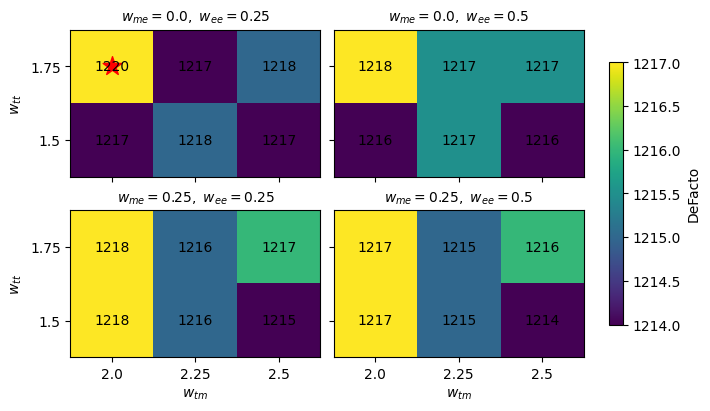

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===== 1. 构造 24 组多因子结果 =====
data = [
    # W_TT, W_TM, W_ME, W_EE, defacto
    [1.5, 2.0, 0.0, 0.25, 1217],
    [1.5, 2.0, 0.0, 0.50, 1216],
    [1.5, 2.0, 0.25, 0.25, 1218],
    [1.5, 2.0, 0.25, 0.50, 1217],

    [1.5, 2.25, 0.0, 0.25, 1218],
    [1.5, 2.25, 0.0, 0.50, 1217],
    [1.5, 2.25, 0.25, 0.25, 1216],
    [1.5, 2.25, 0.25, 0.50, 1215],

    [1.5, 2.50, 0.0, 0.25, 1217],
    [1.5, 2.50, 0.0, 0.50, 1216],
    [1.5, 2.50, 0.25, 0.25, 1215],
    [1.5, 2.50, 0.25, 0.50, 1214],

    [1.75, 2.0, 0.0, 0.25, 1220],
    [1.75, 2.0, 0.0, 0.50, 1218],
    [1.75, 2.0, 0.25, 0.25, 1218],
    [1.75, 2.0, 0.25, 0.50, 1217],

    [1.75, 2.25, 0.0, 0.25, 1217],
    [1.75, 2.25, 0.0, 0.50, 1217],
    [1.75, 2.25, 0.25, 0.25, 1216],
    [1.75, 2.25, 0.25, 0.50, 1215],

    [1.75, 2.50, 0.0, 0.25, 1218],
    [1.75, 2.50, 0.0, 0.50, 1217],
    [1.75, 2.50, 0.25, 0.25, 1217],
    [1.75, 2.50, 0.25, 0.50, 1216],
]

cols = ["w_tt", "w_tm", "w_me", "w_ee", "DeFacto"]
df = pd.DataFrame(data, columns=cols)

# 找出全局最优组合
best_idx = df["DeFacto"].idxmax()
best_row = df.loc[best_idx]

print("Best config:", best_row.to_dict())

# ===== 2. 画 2x2 热力图：行是 W_ME，列是 W_EE =====
me_vals = sorted(df["w_me"].unique())    # [0.0, 0.25]
ee_vals = sorted(df["w_ee"].unique())    # [0.25, 0.5]
tt_vals = sorted(df["w_tt"].unique())    # [1.5, 1.75]
tm_vals = sorted(df["w_tm"].unique())    # [2.0, 2.25, 2.5]

fig, axes = plt.subplots(
    nrows=len(me_vals),
    ncols=len(ee_vals),
    figsize=(7, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True, 
)

# fig.suptitle("Local multi-factor search over edge weights", fontsize=14)

for i, me in enumerate(me_vals):
    for j, ee in enumerate(ee_vals):
        ax = axes[i, j] if axes.ndim > 1 else axes

        # 当前子图对应的子集
        sub = df[(df["w_me"] == me) & (df["w_ee"] == ee)]

        # pivot 成 2x3 的矩阵：行=W_TT，列=W_TM
        heat = sub.pivot(index="w_tt", columns="w_tm", values="DeFacto")
        heat = heat.loc[tt_vals, tm_vals]  # 确保顺序

        im = ax.imshow(heat.values, origin="lower", aspect="auto")

        # 坐标轴刻度
        ax.set_xticks(range(len(tm_vals)))
        ax.set_xticklabels(tm_vals)
        ax.set_yticks(range(len(tt_vals)))
        ax.set_yticklabels(tt_vals)

        if i == len(me_vals) - 1:
            ax.set_xlabel(r"$w_{tm}$")
        if j == 0:
            ax.set_ylabel(r"$w_{tt}$")

        ax.set_title(rf"$w_{{me}}={me},\ w_{{ee}}={ee}$", fontsize=10)

        # 在格子中标注数值
        for r, tt in enumerate(tt_vals):
            for c, tm in enumerate(tm_vals):
                val = heat.loc[tt, tm]
                ax.text(c, r, f"{val:.0f}", ha="center", va="center", fontsize=10)

        # 如果这个格子是全局最优点，画个星星
        if me == best_row["w_me"] and ee == best_row["w_ee"]:
            # 找到最佳点的行列坐标
            r = tt_vals.index(best_row["w_tt"])
            c = tm_vals.index(best_row["w_tm"])
            ax.scatter(c, r, marker="*", s=200,color='red')

# 统一加一个 colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("DeFacto")

# plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("local_multifactor_search_heatmaps.png", dpi=300)
plt.show()
